Note: you may need to restart the kernel to use updated packages.


Using Python 3.12.10 environment at: c:\Projects\FU\.venv
Resolved 1 package in 1.67s
 Downloaded networkx
Prepared 1 package in 624ms
Uninstalled 1 package in 201ms
Installed 1 package in 276ms
 - networkx==3.3
 + networkx==3.6.1


# Задания

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.flow import edmonds_karp

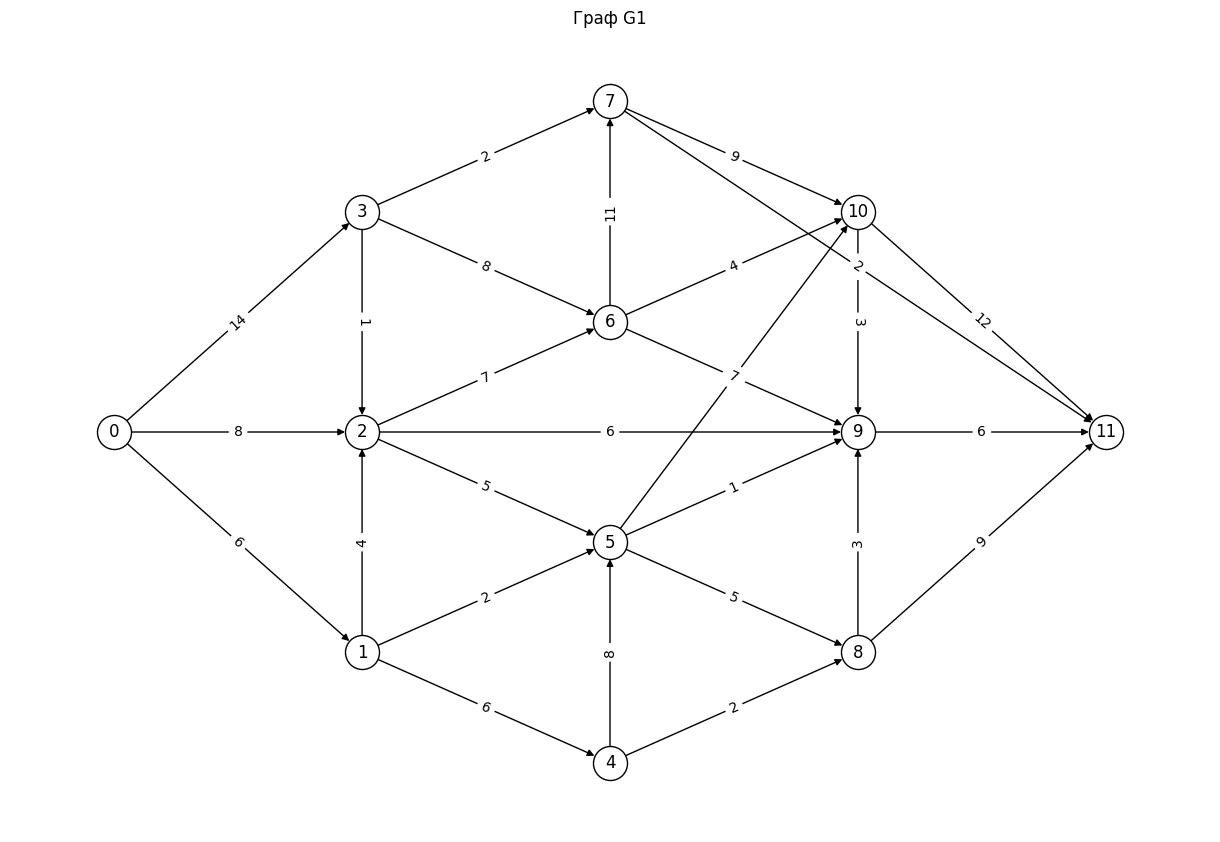

In [ ]:
es =[
    (0, 1, 6), (0, 2, 8), (0, 3, 14), (1, 4, 6), (1, 5, 2), (1, 2, 4),
    (2, 5, 5), (2, 9, 6), (2, 6, 7), (3, 2, 1), (3, 6, 8), (3, 7, 2),
    (4, 8, 2), (4, 5, 8), (5, 8, 5), (5, 9, 1), (5, 10, 6), (6, 9, 7),
    (6, 10, 4), (6, 7, 11), (7, 10, 9), (7, 11, 2), (8, 11, 9), (8, 9, 3),
    (10, 9, 3), (10, 11, 12), (9, 11, 6)
]

g = nx.DiGraph()
for u, v, c in es:
    g.add_edge(u, v, capacity=c, weight=1)

for n in [0]: g.nodes[n]['s'] = 0
for n in [1, 2, 3]: g.nodes[n]['s'] = 1
for n in [4, 5, 6, 7]: g.nodes[n]['s'] = 2
for n in [8, 9, 10]: g.nodes[n]['s'] = 3
for n in [11]: g.nodes[n]['s'] = 4

p = nx.multipartite_layout(g, subset_key='s')

plt.figure(figsize=(12, 8))
nx.draw(g, p, with_labels=True, node_color='w', edgecolors='k', node_size=600)
l = nx.get_edge_attributes(g, 'capacity')
nx.draw_networkx_edge_labels(g, p, edge_labels=l)
plt.title("Граф G1")
plt.show()

25


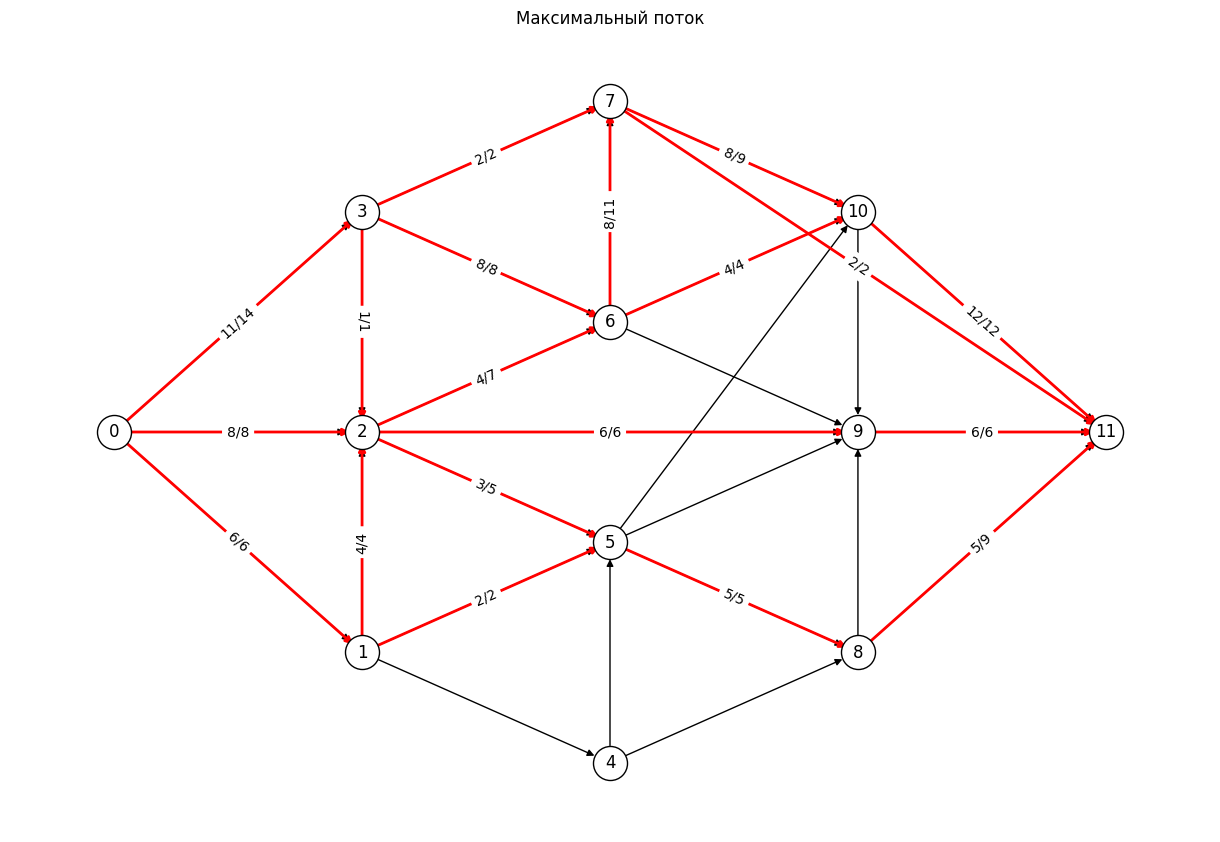

In [6]:
def ff(g, s, t):
    rc = nx.DiGraph()
    for u, v, d in g.edges(data=True):
        if not rc.has_edge(u, v):
            rc.add_edge(u, v, c=0)
        if not rc.has_edge(v, u):
            rc.add_edge(v, u, c=0)
        rc[u][v]['c'] += d['capacity']
        
    mf = 0
    while True:
        vst = {s}
        st = [(s, float('inf'), [s])]
        pt = None
        inc = 0
        while st:
            u, f, cp = st.pop()
            if u == t:
                pt = cp
                inc = f
                break
            for v in rc.neighbors(u):
                if v not in vst and rc[u][v]['c'] > 0:
                    vst.add(v)
                    st.append((v, min(f, rc[u][v]['c']), cp + [v]))
        if not pt:
            break
        mf += inc
        for i in range(len(pt)-1):
            u, v = pt[i], pt[i+1]
            rc[u][v]['c'] -= inc
            rc[v][u]['c'] += inc
            
    fd = {u: {v: 0 for v in g.nodes()} for u in g.nodes()}
    for u, v in g.edges():
        fd[u][v] = g[u][v]['capacity'] - rc[u][v]['c']
        
    return mf, fd

fv, fd = ff(g, 0, 11)
print(fv)

plt.figure(figsize=(12, 8))
nx.draw(g, p, with_labels=True, node_color='w', edgecolors='k', node_size=600)
fl = {(u, v): f"{fd[u][v]}/{g[u][v]['capacity']}" for u, v in g.edges() if fd[u][v] > 0}
nx.draw_networkx_edges(g, p, edgelist=fl.keys(), edge_color='r', width=2)
nx.draw_networkx_edge_labels(g, p, edge_labels=fl)
plt.title("Максимальный поток")
plt.show()

15


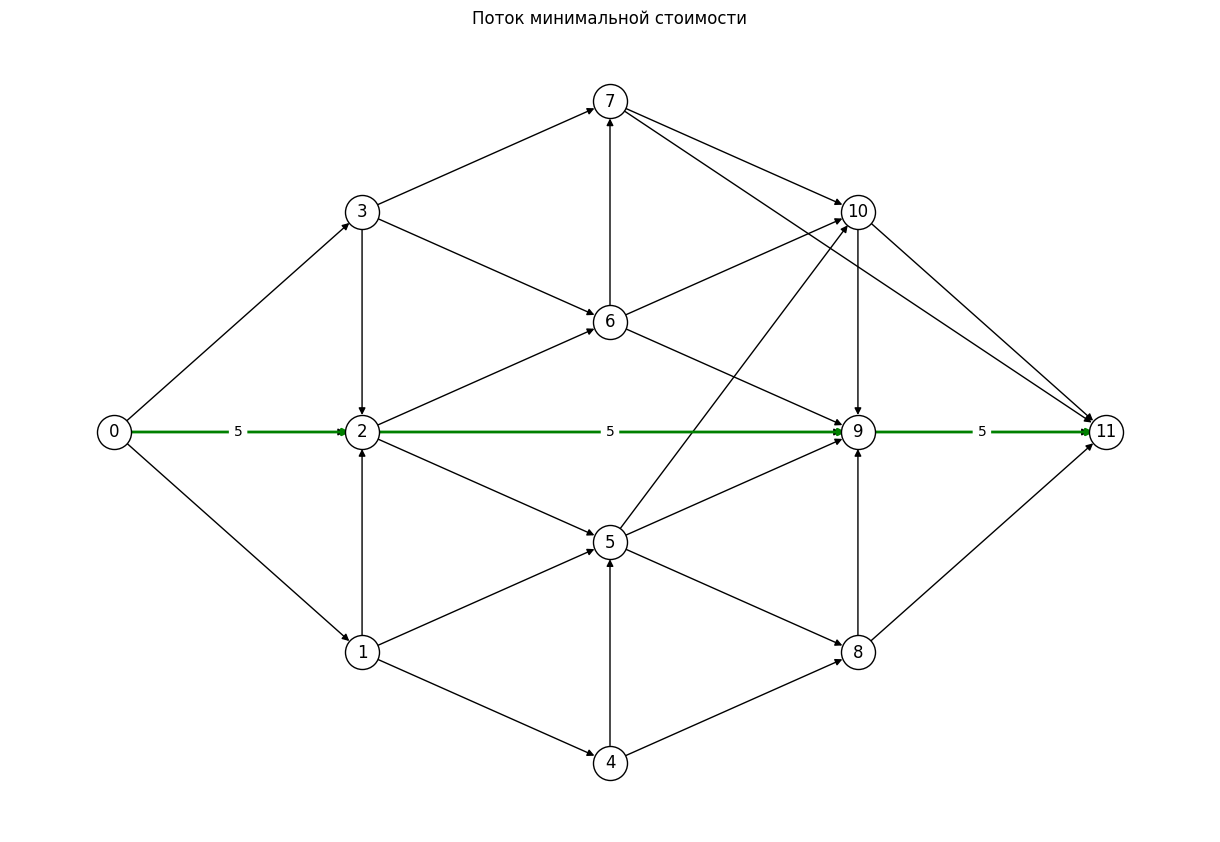

In [5]:
for n in g.nodes():
    g.nodes[n]['demand'] = 0
g.nodes[0]['demand'] = -5
g.nodes[11]['demand'] = 5

mcd = nx.min_cost_flow(g)
cst = nx.cost_of_flow(g, mcd)
print(cst)

plt.figure(figsize=(12, 8))
nx.draw(g, p, with_labels=True, node_color='w', edgecolors='k', node_size=600)
mfl = {(u, v): f"{mcd[u][v]}" for u, v in g.edges() if mcd[u][v] > 0}
nx.draw_networkx_edges(g, p, edgelist=mfl.keys(), edge_color='g', width=2)
nx.draw_networkx_edge_labels(g, p, edge_labels=mfl)
plt.title("Поток минимальной стоимости")
plt.show()

# Задания для самостоятельного выполнения

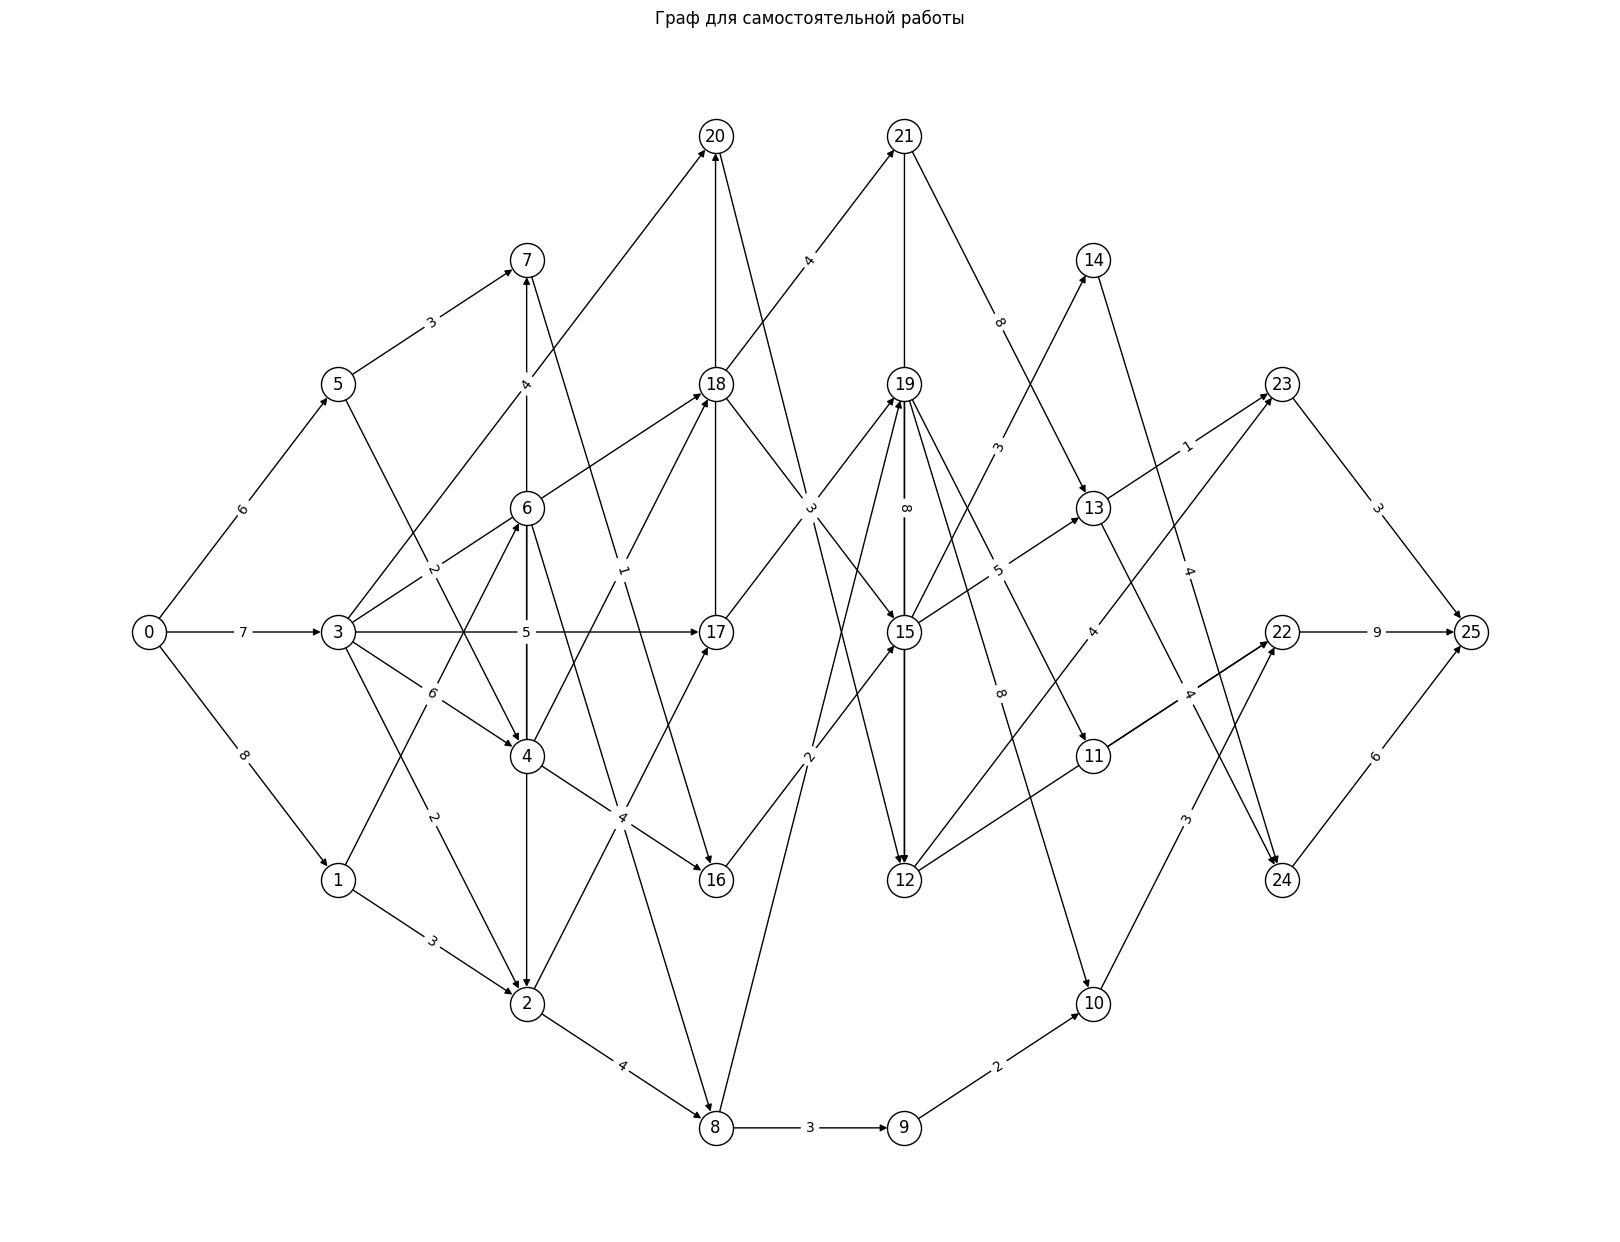

In [7]:
es2 =[
    (0, 1, 8), (0, 3, 7), (0, 5, 6), (1, 6, 6), (1, 2, 3),
    (3, 2, 2), (3, 17, 5), (3, 20, 4), (3, 18, 1), (3, 4, 6),
    (5, 4, 2), (5, 7, 3), (6, 2, 2), (6, 8, 7), (2, 8, 4),
    (2, 17, 3), (4, 18, 3), (4, 7, 1), (4, 16, 4), (7, 16, 1),
    (8, 9, 3), (8, 19, 2), (17, 19, 10), (17, 20, 5), (20, 12, 2),
    (18, 21, 4), (18, 15, 3), (16, 15, 2), (9, 10, 2), (19, 10, 8),
    (19, 11, 7), (19, 12, 8), (21, 12, 8), (21, 13, 8), (15, 13, 5),
    (15, 14, 3), (10, 22, 3), (11, 22, 2), (12, 22, 10), (12, 23, 4),
    (13, 23, 1), (13, 24, 4), (14, 24, 4), (22, 25, 9), (23, 25, 3),
    (24, 25, 6)
]

g2 = nx.DiGraph()
for u, v, c in es2:
    g2.add_edge(u, v, capacity=c, weight=1)

ls = [
    [0], [1, 3, 5],[6, 2, 4, 7],[8, 17, 20, 18, 16],[9, 19, 12, 21, 15], [10, 11, 13, 14],[22, 23, 24], [25]
]

for i, l in enumerate(ls):
    for n in l:
        g2.nodes[n]['s'] = i

p2 = nx.multipartite_layout(g2, subset_key='s')

plt.figure(figsize=(16, 12))
nx.draw(g2, p2, with_labels=True, node_color='w', edgecolors='k', node_size=600)
l2 = nx.get_edge_attributes(g2, 'capacity')
nx.draw_networkx_edge_labels(g2, p2, edge_labels=l2)
plt.title("Граф для самостоятельной работы")
plt.show()

17


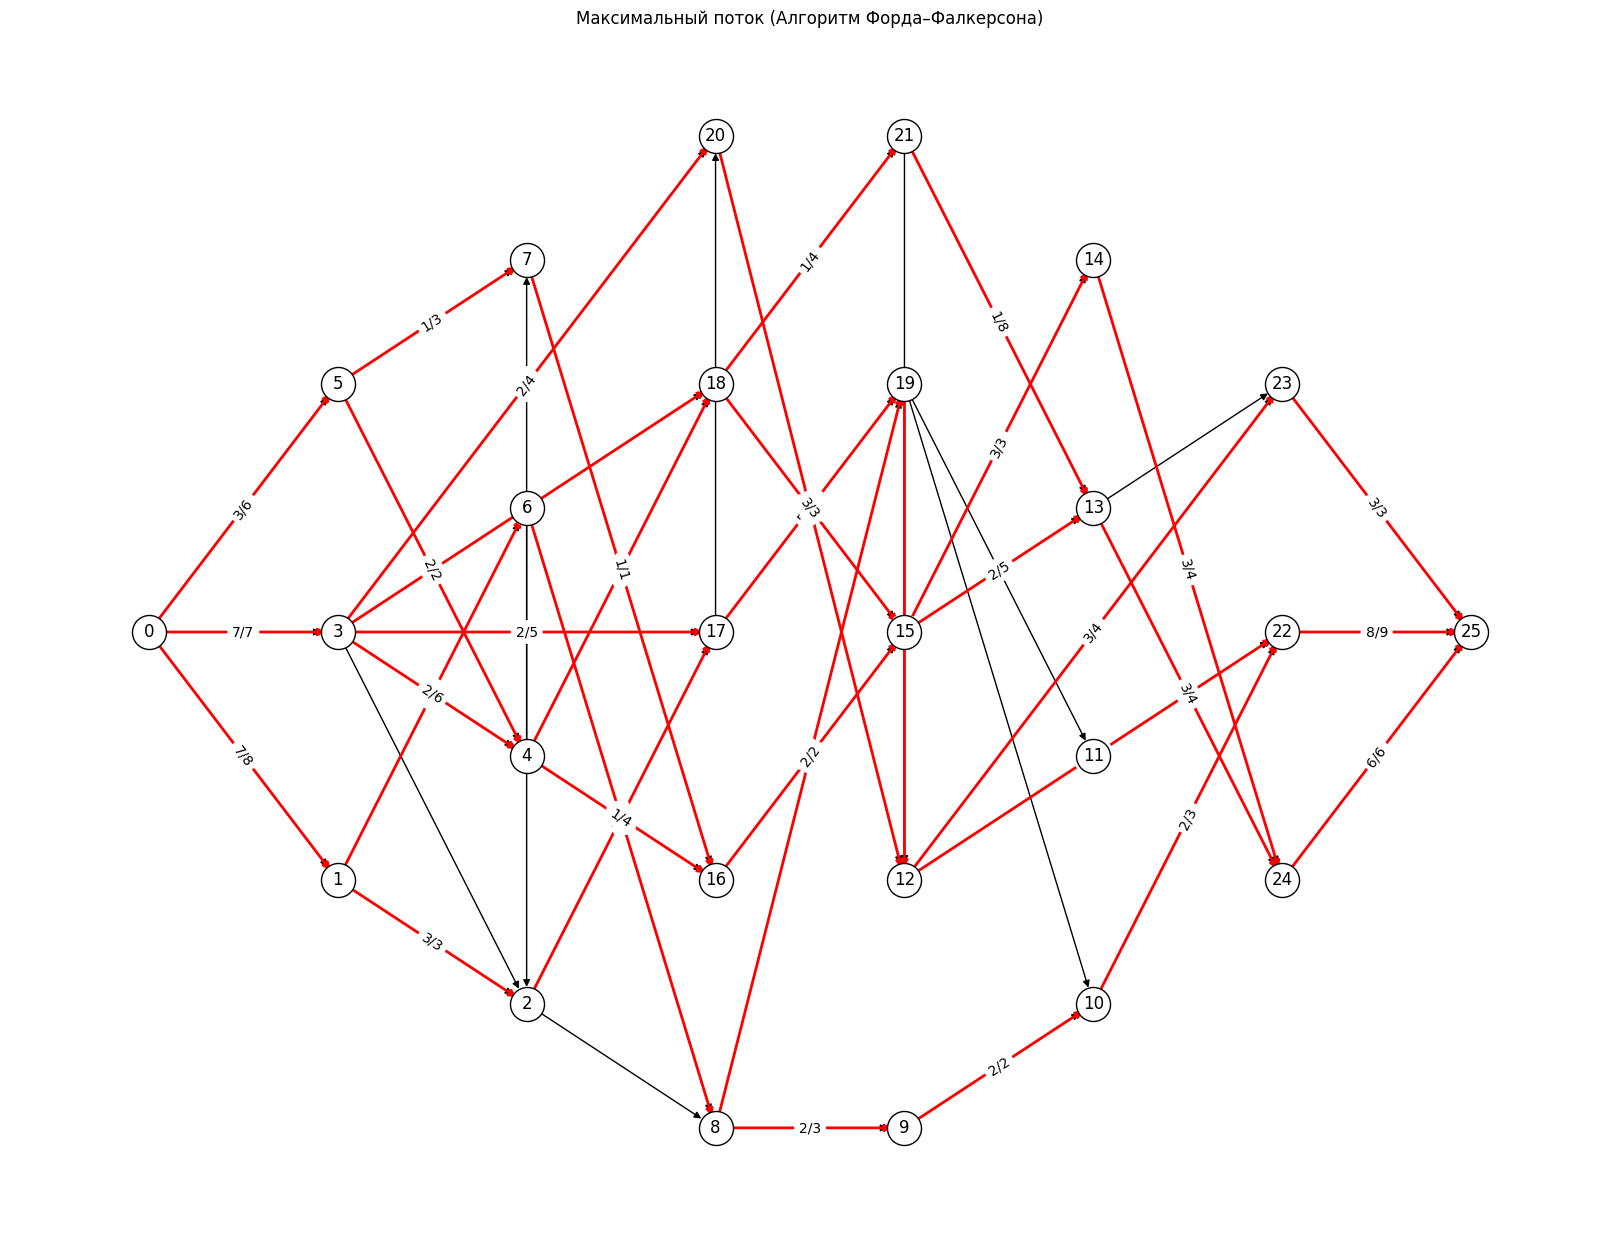

In [8]:
fv2, fd2 = ff(g2, 0, 25)
print(fv2)

plt.figure(figsize=(16, 12))
nx.draw(g2, p2, with_labels=True, node_color='w', edgecolors='k', node_size=600)
fl2 = {(u, v): f"{fd2[u][v]}/{g2[u][v]['capacity']}" for u, v in g2.edges() if fd2[u][v] > 0}
nx.draw_networkx_edges(g2, p2, edgelist=fl2.keys(), edge_color='r', width=2)
nx.draw_networkx_edge_labels(g2, p2, edge_labels=fl2)
plt.title("Максимальный поток (Алгоритм Форда–Фалкерсона)")
plt.show()

40


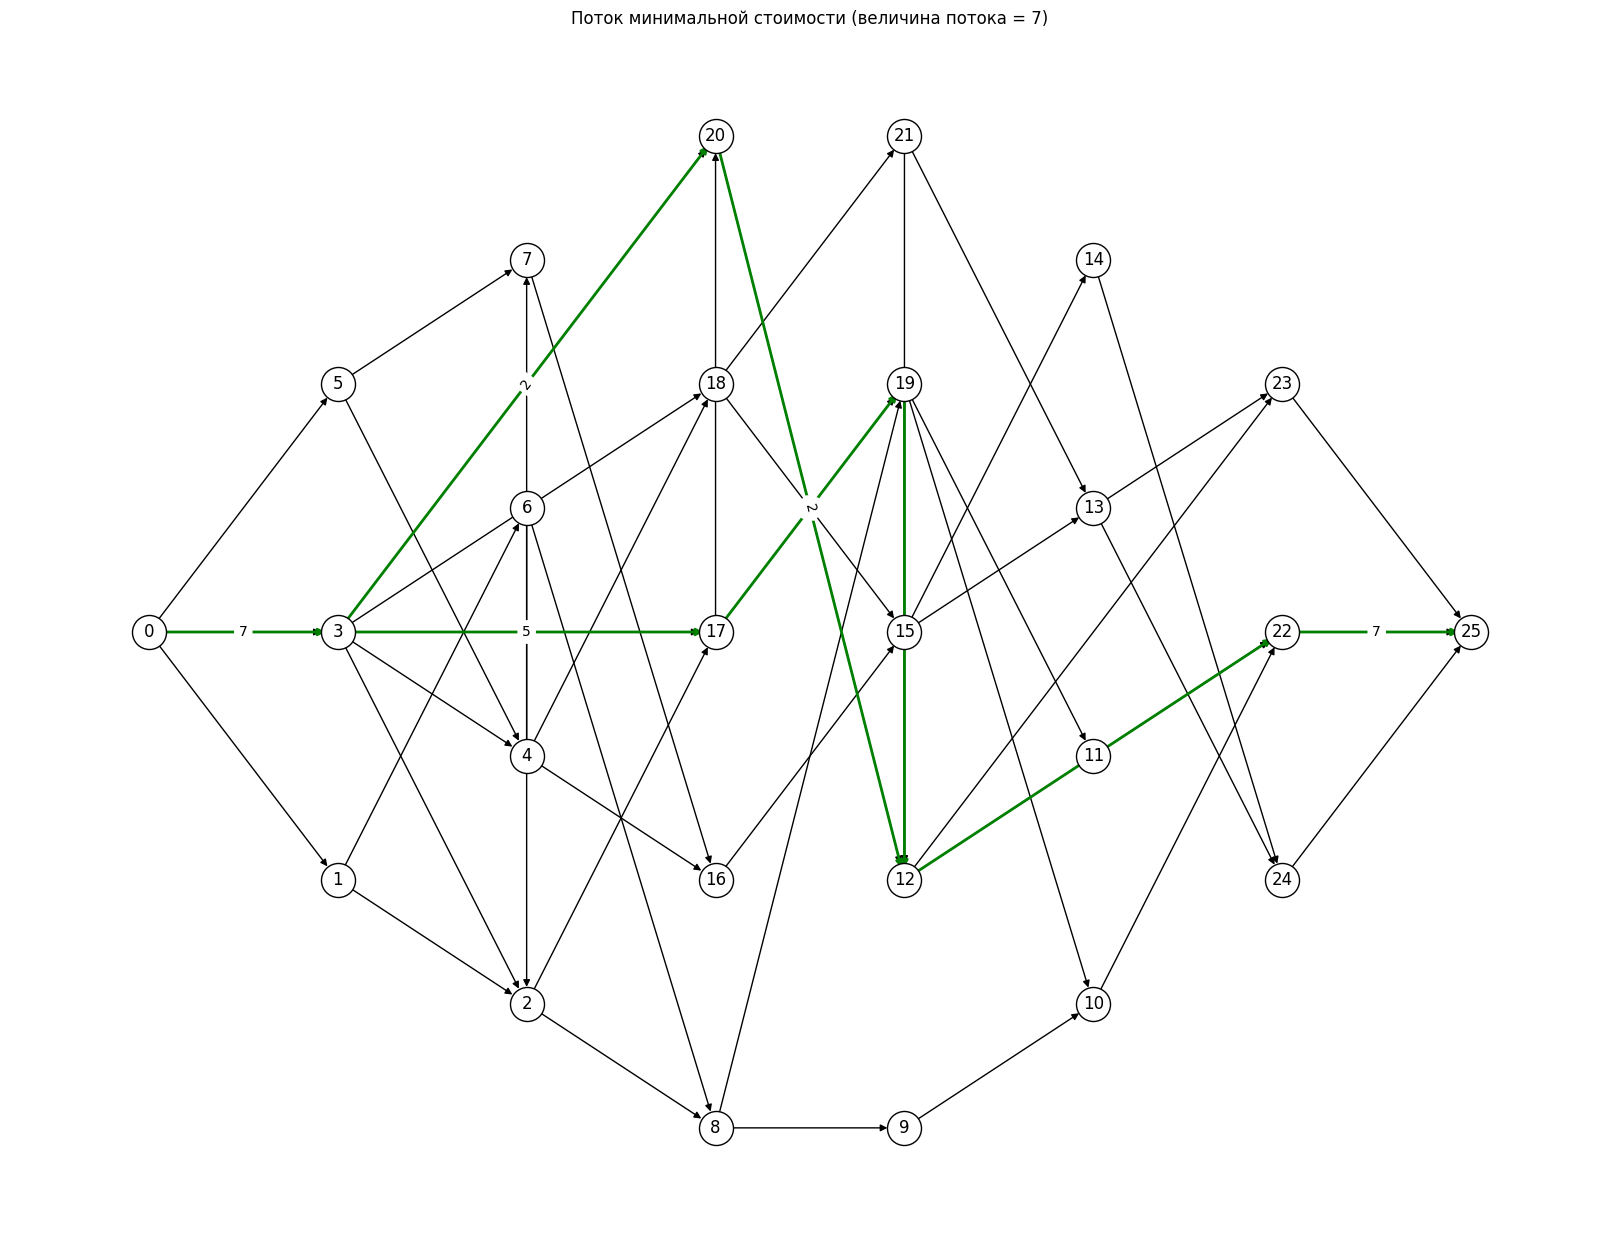

In [9]:
for n in g2.nodes():
    g2.nodes[n]['demand'] = 0
g2.nodes[0]['demand'] = -7
g2.nodes[25]['demand'] = 7

mcd2 = nx.min_cost_flow(g2)
cst2 = nx.cost_of_flow(g2, mcd2)
print(cst2)

plt.figure(figsize=(16, 12))
nx.draw(g2, p2, with_labels=True, node_color='w', edgecolors='k', node_size=600)
mfl2 = {(u, v): f"{mcd2[u][v]}" for u, v in g2.edges() if mcd2[u][v] > 0}
nx.draw_networkx_edges(g2, p2, edgelist=mfl2.keys(), edge_color='g', width=2)
nx.draw_networkx_edge_labels(g2, p2, edge_labels=mfl2)
plt.title("Поток минимальной стоимости (величина потока = 7)")
plt.show()

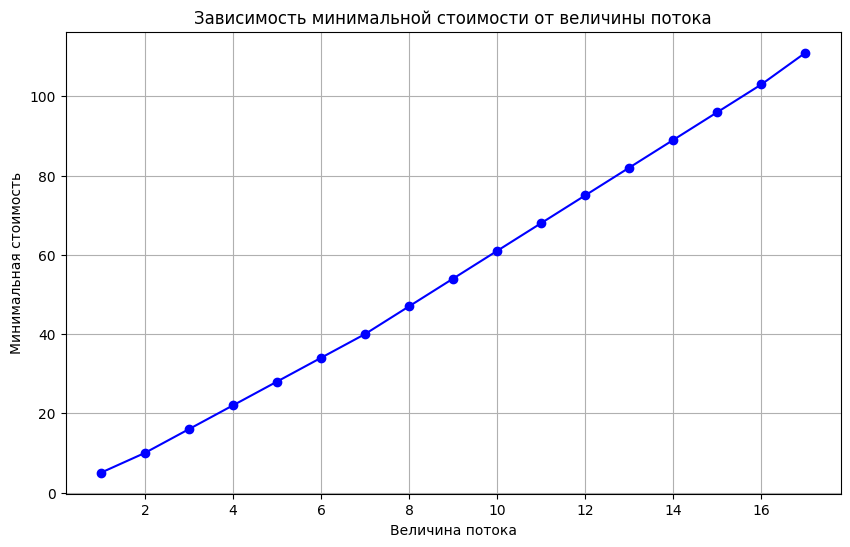

In [10]:
mnc = min(d['capacity'] for u, v, d in g2.edges(data=True))
mxc = fv2

fs = list(range(mnc, mxc + 1))
cs = []
fds =[]

for f in fs:
    for n in g2.nodes():
        g2.nodes[n]['demand'] = 0
    g2.nodes[0]['demand'] = -f
    g2.nodes[25]['demand'] = f
    
    d = nx.min_cost_flow(g2)
    c = nx.cost_of_flow(g2, d)
    cs.append(c)
    fds.append(d)

plt.figure(figsize=(10, 6))
plt.plot(fs, cs, marker='o', color='b')
plt.xlabel("Величина потока")
plt.ylabel("Минимальная стоимость")
plt.title("Зависимость минимальной стоимости от величины потока")
plt.grid(True)
plt.show()